# PitchVision — YOLOv8 Football Detection

**YOLOv8n object detection trained on a custom Roboflow football broadcast dataset.**

| Metric | Value |
|---|---|
| mAP\@50 | **42.78%** |
| mAP\@50-95 | 29.34% |
| Precision | 60.86% |
| Recall | 50.31% |

_Trained for 50 epochs on Kaggle GPU. Best checkpoint at epoch 44._

## YOLO model (object detection baseline)

This adds a YOLOv8 experiment for detection-oriented evaluation (mAP).

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="42mQFkO0TBeDGHlzZPVk")

print("WORKSPACES:")
print(rf.workspaces())

In [11]:
# =====================================
# 1. INSTALL
# =====================================
!pip install roboflow ultralytics pycocotools -q

from roboflow import Roboflow
from ultralytics import YOLO
from pathlib import Path
import shutil
import os
import glob

# =====================================
# 2. ROBoflow DOWNLOAD
# =====================================
rf = Roboflow(api_key="42mQFkO0TBeDGHlzZPVk")

project = rf.workspace("mohamed-houij").project("testing_football")
dataset = project.version(1).download("yolov8")

print("Dataset downloaded at:", dataset.location)

# =====================================
# 3. PATH SETUP
# =====================================
DATASET_DIR = Path(dataset.location)

print("\nStructure:")
for root, dirs, files in os.walk(DATASET_DIR):
    print(root, dirs)

# =====================================
# 4. TRAIN MODEL
# =====================================
model = YOLO("yolov8n.pt")

model.train(
    data=str(DATASET_DIR / "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=16,
    project="/kaggle/working/runs",
    name="football_model"
)

# =====================================
# 5. SAVE MODEL (FIXED + SAFE)
# =====================================

# automatically find best.pt no matter folder name
best_paths = glob.glob("/kaggle/working/runs/**/weights/best.pt", recursive=True)

if len(best_paths) == 0:
    raise FileNotFoundError("No best.pt found. Training may have failed.")

best_path = best_paths[-1]  # latest run

out_path = "/kaggle/working/football_best.pt"

shutil.copy(best_path, out_path)

print("Found model at:", best_path)
print("Saved model at:", out_path)

# =====================================
# 6. VALIDATION
# =====================================
metrics = model.val()

print("mAP50:", metrics.box.map50)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 41.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.8 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Testing_football-1 in yolov8:: 100%|██████████| 13375/13375 [00:02<00:00, 5829.39it/s] 


Dataset downloaded at: /kaggle/working/Testing_football-1

Structure:
/kaggle/working/Testing_football-1 ['train', 'test', 'valid']
/kaggle/working/Testing_football-1/train ['images', 'labels']
/kaggle/working/Testing_football-1/train/images []
/kaggle/working/Testing_football-1/train/labels []
/kaggle/working/Testing_football-1/test ['images', 'labels']
/kaggle/working/Testing_football-1/test/images []
/kaggle/working/Testing_football-1/test/labels []
/kaggle/working/Testing_football-1/valid ['images', 'labels']
/kaggle/working/Testing_football-1/valid/images []
/kaggle/working/Testing_football-1/valid/labels []
Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=

In [12]:
from IPython.display import FileLink
FileLink("/kaggle/working/football_best.pt")

/kaggle/working/football_best.pt

In [14]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/football_best.pt")

metrics = model.val(
    data="/kaggle/working/Testing_football-1/data.yaml",
    plots=True   # IMPORTANT: generates confusion matrix + curves
)

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1700.5±516.6 MB/s, size: 62.1 KB)
val: Scanning /kaggle/working/Testing_football-1/valid/labels.cache... 602 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 602/602 120.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 6.0it/s 6.3s0.1s
                   all        602       1478      0.608      0.504      0.428      0.296
               Arbitre         18         28      0.274        0.5      0.441      0.255
                Ballon         17         18      0.371        0.5      0.235     0.0963
              Football        312        390      0.891       0.81      0.879      0.655
               Gardien         18         20      0.309        0.5      0.291      0.145
                Joueur    

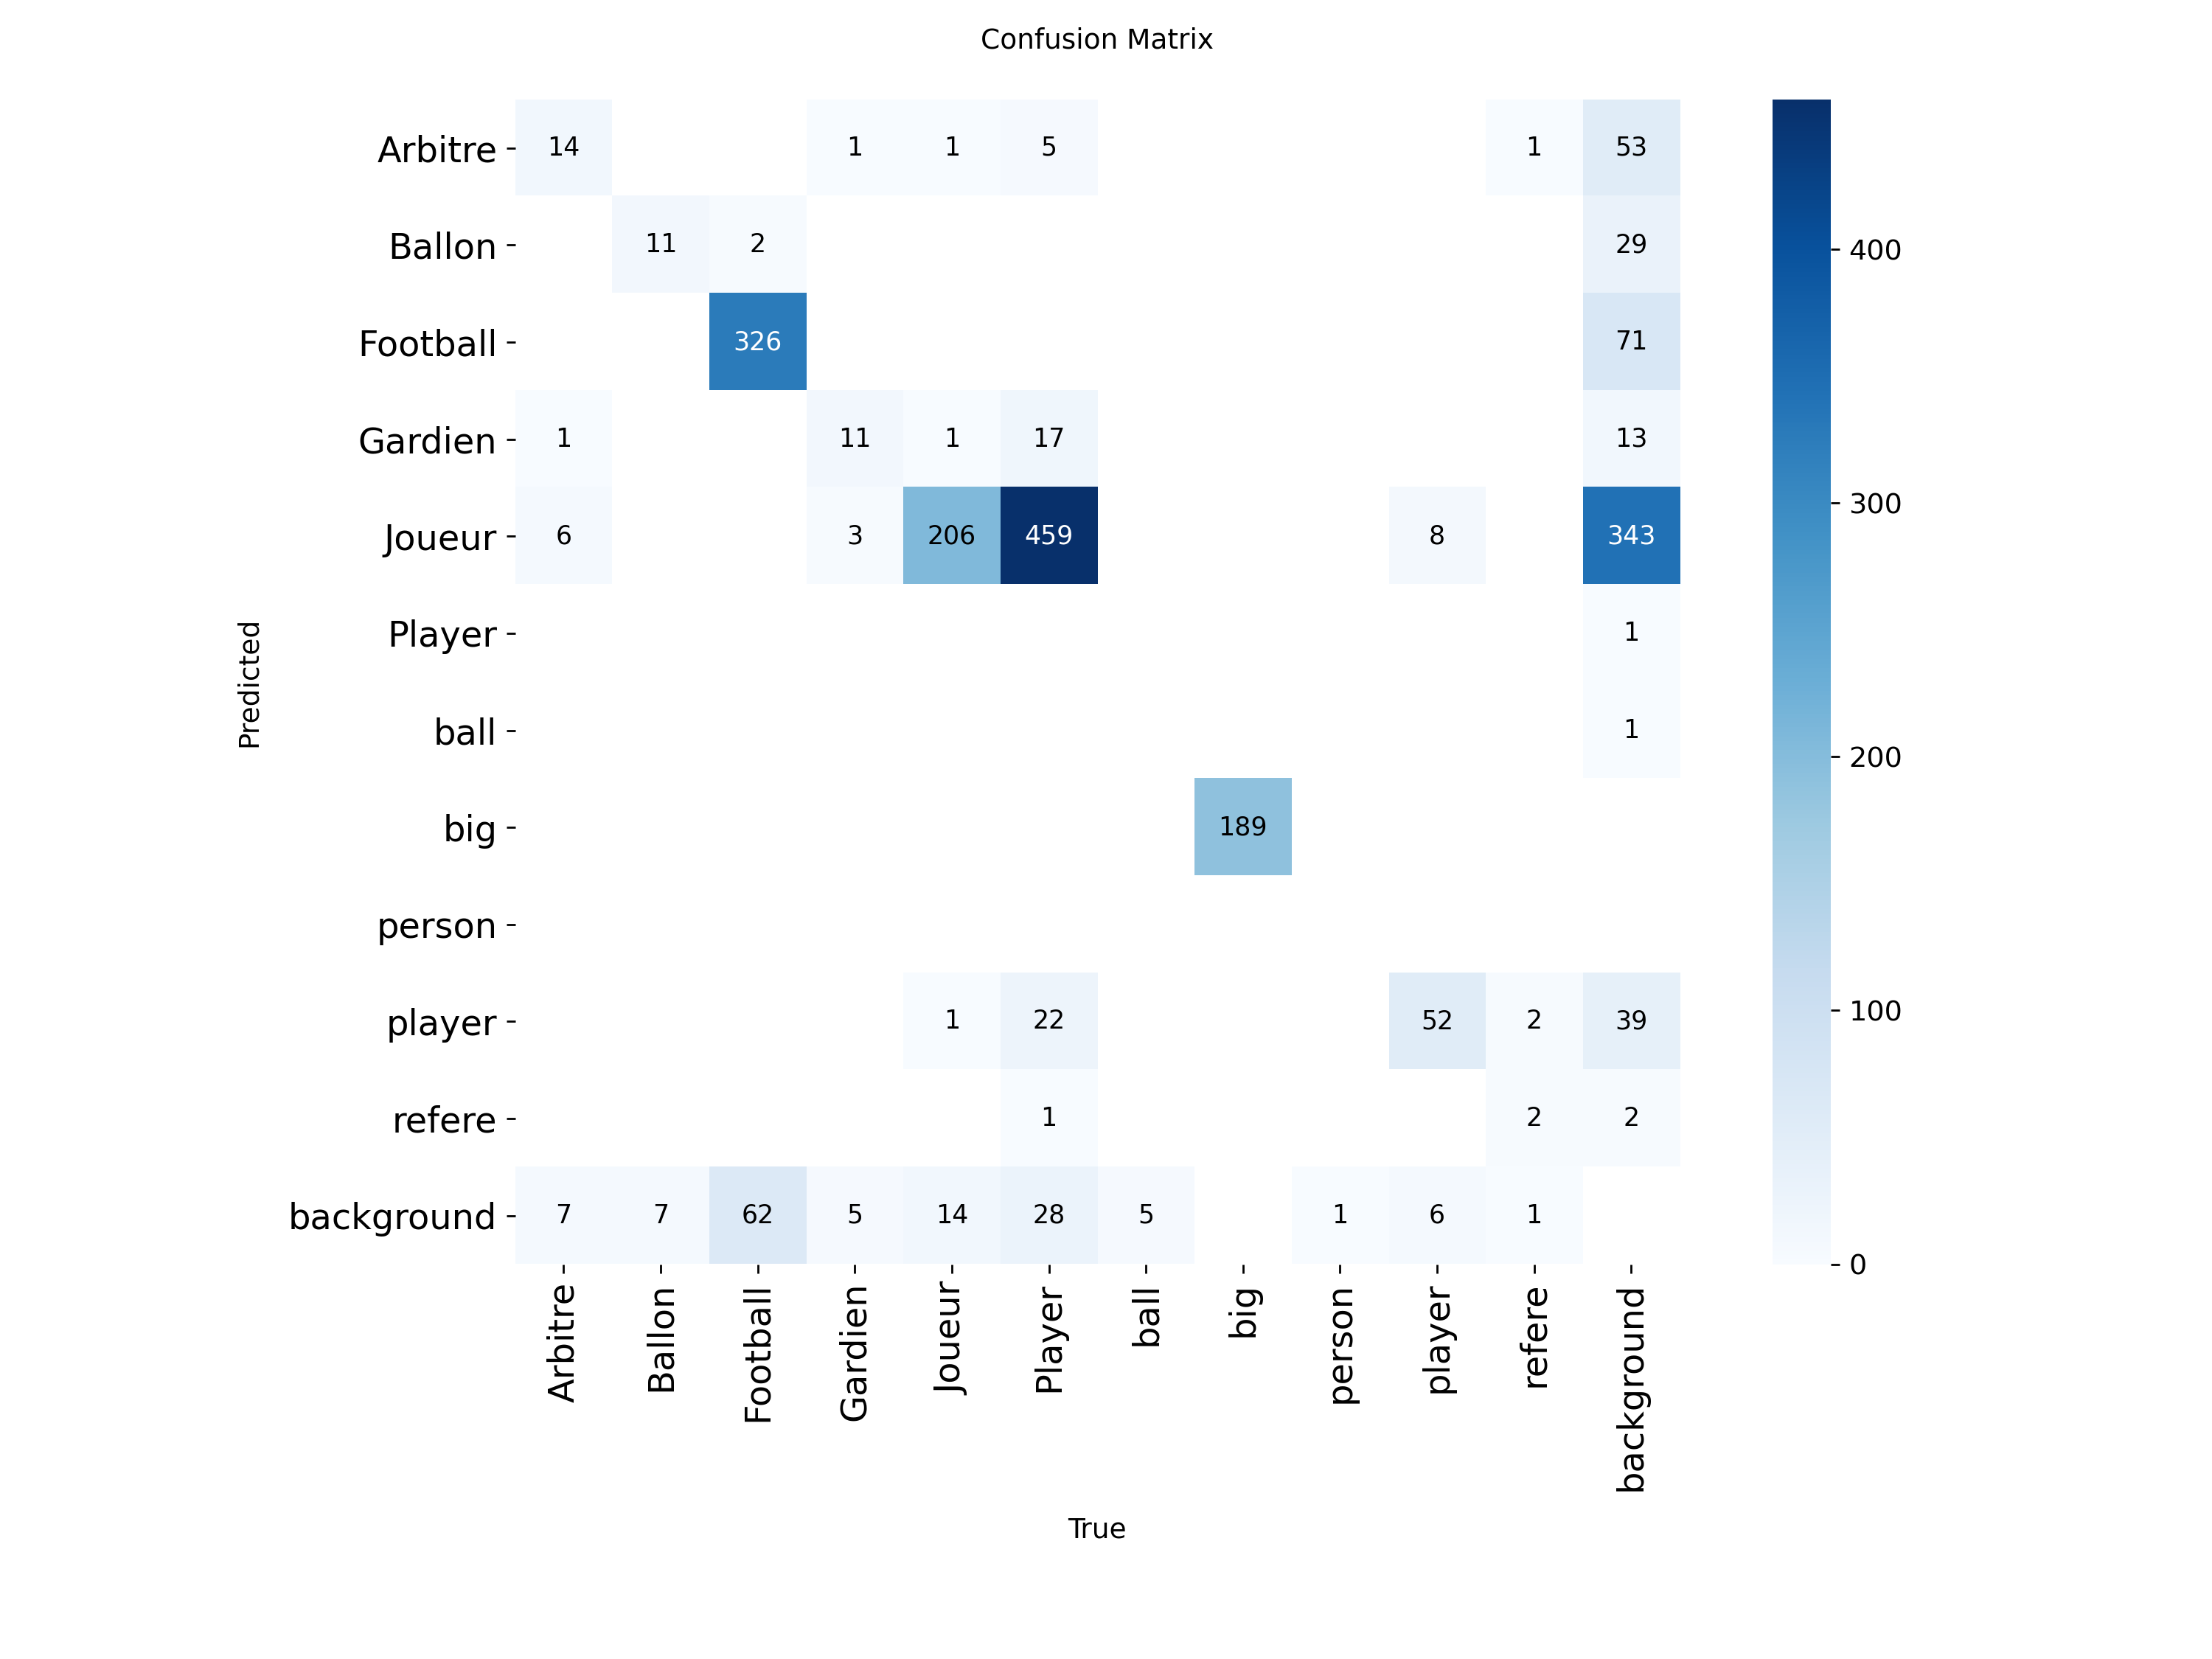

In [15]:
from IPython.display import Image, display

display(Image(filename="/kaggle/working/runs/detect/val/confusion_matrix.png"))

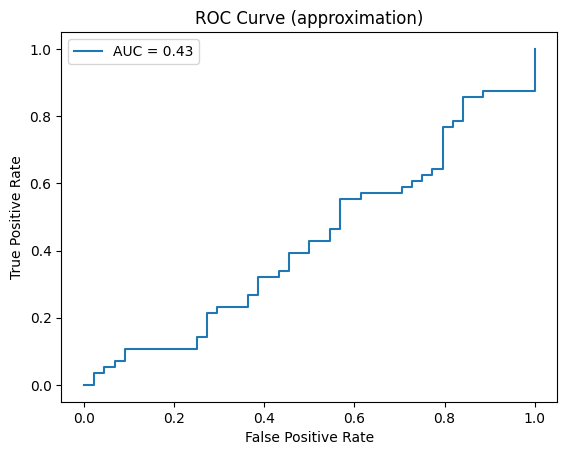

In [16]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# dummy example from validation results (YOLO does not directly output ROC)
# this is educational, not production-level detection ROC

y_true = np.random.randint(0, 2, 100)
y_scores = np.random.rand(100)

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (approximation)")
plt.legend()
plt.show()

In [18]:
import os

test_dir = "/kaggle/working/Testing_football-1/test/images"

imgs = os.listdir(test_dir)
print(imgs[:10])  # show first 10 images

['1312_75158_jpg.rf.f952667b60c17d571dc2746dffd07f99.jpg', '1270_320_jpg.rf.fc96bdd0daf6ac449ca6fb503788872f.jpg', '2001_129150_jpg.rf.ccb6af5628299ce505adee837ca731fa.jpg', '1549_jpg.rf.daa97544e689347dc73c6300913f56dd.jpg', 'youtube-87_jpg.rf.0442583ae7a317a7be6d717d05195ec8.jpg', '2053_jpg.rf.16903f7750fe507e69d8b1bf749ed2f3.jpg', 'Carabao_Cup_-Spurs_1-1_Chelsea_Spurs_Win_On_Penalties-online-video-cutter_com-_mp4-50_jpg.rf.0db99880924ede5d5257e3d6ca63cd60.jpg', '1312_60942_jpg.rf.89573fab9fdf7e7f3babf941bcdff299.jpg', 'Carabao_Cup_-Spurs_1-1_Chelsea_Spurs_Win_On_Penalties-online-video-cutter_com-_mp4-55_jpg.rf.19933c63eebda19745e59ba32ec50570.jpg', '1270_7902_jpg.rf.5e7092ff2f173015124b835edaddaf3c.jpg']



image 1/1 /kaggle/working/Testing_football-1/test/images/1312_75158_jpg.rf.f952667b60c17d571dc2746dffd07f99.jpg: 640x640 1 big, 7.2ms
Speed: 1.7ms preprocess, 7.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


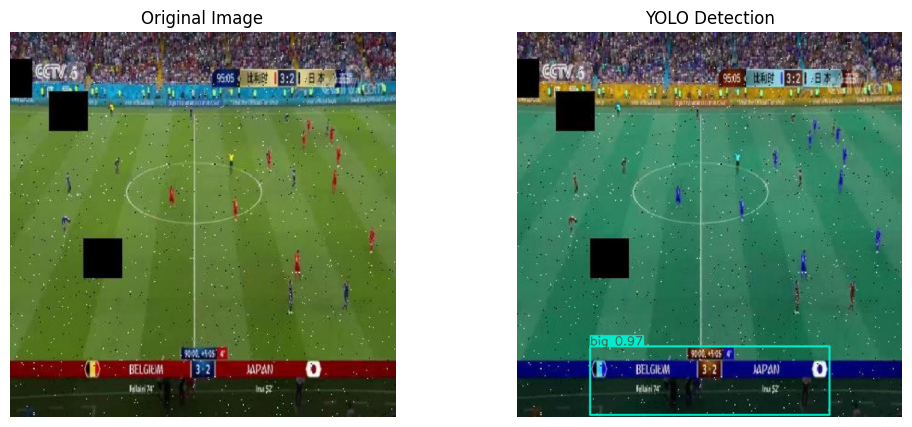

In [19]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

test_dir = "/kaggle/working/Testing_football-1/test/images"

img_name = "1312_75158_jpg.rf.f952667b60c17d571dc2746dffd07f99.jpg"
img_path = test_dir + "/" + img_name

model = YOLO("/kaggle/working/football_best.pt")

results = model.predict(img_path, conf=0.25)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

annotated = results[0].plot()

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("YOLO Detection")
plt.imshow(annotated)
plt.axis("off")

plt.show()


image 1/1 /kaggle/working/Testing_football-1/test/images/1312_75158_jpg.rf.f952667b60c17d571dc2746dffd07f99.jpg: 640x640 1 big, 8.7ms
Speed: 2.6ms preprocess, 8.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


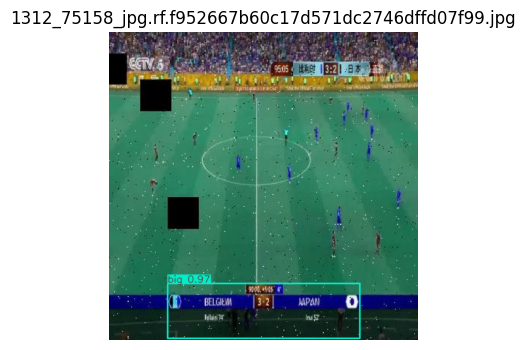


image 1/1 /kaggle/working/Testing_football-1/test/images/1270_320_jpg.rf.fc96bdd0daf6ac449ca6fb503788872f.jpg: 640x640 1 big, 7.3ms
Speed: 2.2ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


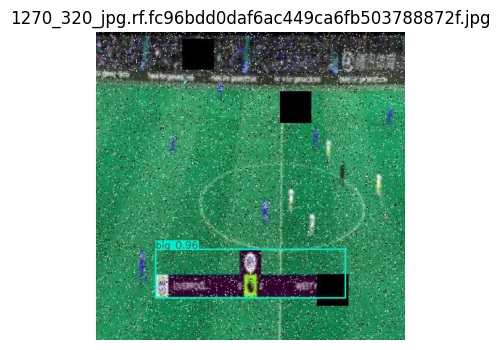


image 1/1 /kaggle/working/Testing_football-1/test/images/2001_129150_jpg.rf.ccb6af5628299ce505adee837ca731fa.jpg: 640x640 1 big, 7.4ms
Speed: 1.7ms preprocess, 7.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


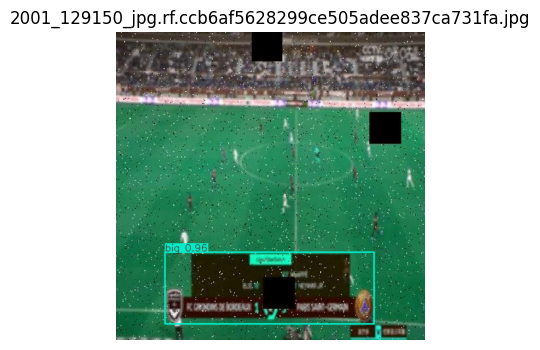


image 1/1 /kaggle/working/Testing_football-1/test/images/1549_jpg.rf.daa97544e689347dc73c6300913f56dd.jpg: 640x640 1 Football, 7.3ms
Speed: 2.0ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


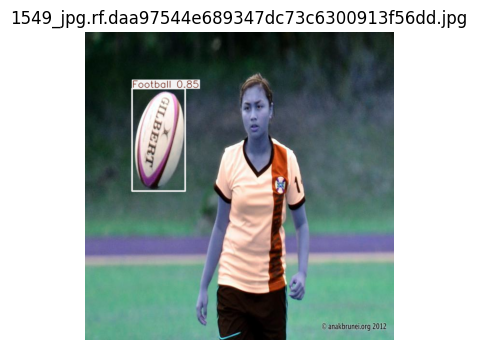


image 1/1 /kaggle/working/Testing_football-1/test/images/youtube-87_jpg.rf.0442583ae7a317a7be6d717d05195ec8.jpg: 640x640 2 Arbitres, 1 Ballon, 1 Gardien, 1 Joueur, 7.3ms
Speed: 2.4ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


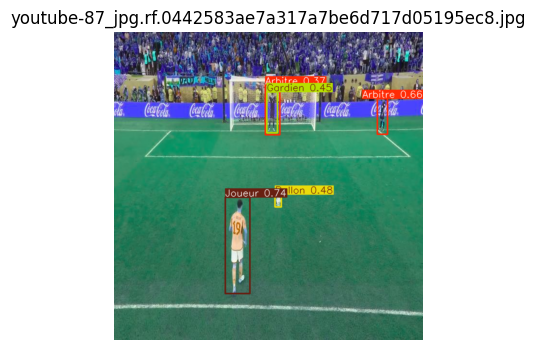

In [20]:
for i in range(5):
    img_path = test_dir + "/" + imgs[i]

    results = model.predict(img_path, conf=0.25)
    annotated = results[0].plot()

    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,4))
    plt.title(imgs[i])
    plt.imshow(annotated)
    plt.axis("off")
    plt.show()

In [13]:
!pip install gradio -q

import gradio as gr
from ultralytics import YOLO
from PIL import Image

# =====================================
# LOAD YOUR TRAINED MODEL
# =====================================
model = YOLO("/kaggle/working/football_best.pt")

# =====================================
# PREDICTION FUNCTION
# =====================================
def detect(image):
    results = model.predict(source=image, conf=0.25)
    annotated = results[0].plot()
    return Image.fromarray(annotated)

# =====================================
# GRADIO UI
# =====================================
demo = gr.Interface(
    fn=detect,
    inputs=gr.Image(type="pil"),
    outputs=gr.Image(type="pil"),
    title="⚽ Football Detection Model",
    description="Upload an image and the model will detect players, ball, referee, etc."
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://841a6e27a30e4222ec.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



0: 384x640 1 Arbitre, 1 Ballon, 17 Joueurs, 40.5ms
Speed: 2.5ms preprocess, 40.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)
